In [1]:

import pandas as pd
from sklearn.datasets import fetch_california_housing

# Load the dataset
housing = fetch_california_housing(as_frame=True)

# Create a DataFrame
df = housing.frame

# Display the first five rows
print(df.head())

# Check dataset size
print("Dataset shape:", df.shape)

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
Dataset shape: (20640, 9)

Missing values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [2]:

from sklearn.model_selection import train_test_split

# Input features
X = df.drop("MedHouseVal", axis=1)

# Target value to predict
y = df["MedHouseVal"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Number of input features:", X_train.shape[1])

Training samples: 16512
Testing samples: 4128
Number of input features: 8


In [3]:

from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("House Price Prediction model trained successfully!")

House Price Prediction model trained successfully!


In [4]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predict prices for test data
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("------------------------")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"R² Percentage: {r2 * 100:.2f}%")

Model Evaluation Results
------------------------
Mean Absolute Error (MAE): 0.5332
Mean Squared Error (MSE): 0.5559
Root Mean Squared Error (RMSE): 0.7456
R² Score: 0.5758
R² Percentage: 57.58%


In [5]:

results = pd.DataFrame({
    "Actual Price ($100,000s)": y_test.values[:10],
    "Predicted Price ($100,000s)": y_pred[:10]
})

results["Actual Price ($)"] = results["Actual Price ($100,000s)"] * 100000
results["Predicted Price ($)"] = results["Predicted Price ($100,000s)"] * 100000

print(results.round(2))

   Actual Price ($100,000s)  Predicted Price ($100,000s)  Actual Price ($)  \
0                      0.48                         0.72           47700.0   
1                      0.46                         1.76           45800.0   
2                      5.00                         2.71          500001.0   
3                      2.19                         2.84          218600.0   
4                      2.78                         2.60          278000.0   
5                      1.59                         2.01          158700.0   
6                      1.98                         2.65          198200.0   
7                      1.58                         2.17          157500.0   
8                      3.40                         2.74          340000.0   
9                      4.47                         3.92          446600.0   

   Predicted Price ($)  
0             71912.28  
1            176401.66  
2            270965.88  
3            283892.59  
4            260

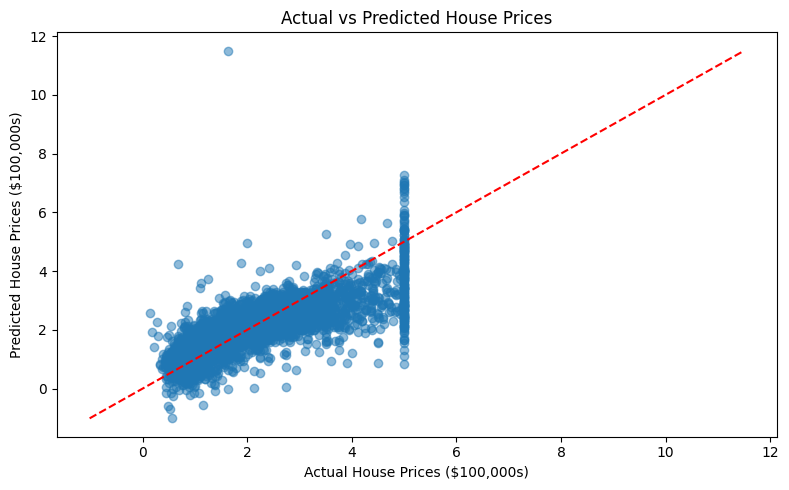

In [6]:

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual House Prices ($100,000s)")
plt.ylabel("Predicted House Prices ($100,000s)")
plt.title("Actual vs Predicted House Prices")

# Reference line for perfect predictions
minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())
plt.plot([minimum, maximum], [minimum, maximum], "r--")

plt.tight_layout()
plt.savefig("actual_vs_predicted.png")
plt.show()

In [7]:

sample_house = pd.DataFrame([{
    "MedInc": 5.0,
    "HouseAge": 30.0,
    "AveRooms": 5.5,
    "AveBedrms": 1.1,
    "Population": 1000.0,
    "AveOccup": 3.0,
    "Latitude": 34.05,
    "Longitude": -118.25
}])

predicted_value = model.predict(sample_house)[0]

print(f"Predicted median house value: ${predicted_value * 100000:,.2f}")

Predicted median house value: $267,444.15


In [8]:

import joblib

joblib.dump(model, "house_price_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [9]:

from google.colab import files

files.download("house_price_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:

files.download("actual_vs_predicted.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>